# KOBEsim example: mock dataset

In this tutorial:
- We simulate the RV dataset of a 25 Earth mass planet orbiting a K-dwarf host star with a period of $P = 60.3$ days.

Let's start with some general imports and set ups

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.timeseries import LombScargle
from scipy.signal import find_peaks
import sys

EXAMPLE_DIR = Path.cwd().resolve()
REPO_ROOT = EXAMPLE_DIR.parent
sys.path.insert(0, str(REPO_ROOT))

# dataset name
path_data = "data/mock_rv_25Me_60d_new.csv"

# constants
cte_G = 6.6743e-11   # m**3/(kg * s**2)
me_to_kg = 5.9722e24 # Mass of the Earth
ms_to_kg = 1.9891e30
d_to_s = 24 * 3600

# periodogram set-up
n_peaks = 1
min_per_d = 3
max_per_d = 160.0

# general
star = 'KOBE-1' # name of the star
BJD_offset = 2_450_000
peak_colors = ["m", "dodgerblue"]

## Simulation

We use a function from KOBEsim module to create the mock dataset.

In [2]:
import modules_KOBEsim.run_MCMC as KOBEsimMod

# random array of observations [BJD - 2450000]
n_obs = 50
timespan = 300
t = np.sort(np.random.uniform(9800., 9800. + timespan, n_obs))

#----- Planet parameters ------#
Vsys = 0  # m/s
P = 60.3  # days
inc = 90  # deg
Mp = 25   # M_Earth
Ms = 0.6  # M_Sun
ecc = 0
w = np.radians(0)
t0 = t[5] + np.random.uniform(0, 1)
#------------------------------#

# units m/s
K = Mp * me_to_kg * np.sin(np.radians(inc)) * (1 - ecc**2)**(-1/2) * (Mp * me_to_kg + Ms * ms_to_kg)**(-2/3) * (2 * np.pi * cte_G / (P * d_to_s))**(1/3)
secosw = np.sqrt(ecc) * np.cos(w)
sesinw = np.sqrt(ecc) * np.sin(w)

# parameters Linear and Quadratic trends
m = 0
q = 0

# units m/s
rv_keplerian = KOBEsimMod.model_RV(Vsys, P, K, t0, secosw, sesinw, m, q, t, planet = True)[0]

We add white noise and simulate associated uncertainties to the mock RV meaurements

In [3]:
mu_noise, std_noise = 0., 3.
mu_erv, std_erv = 3., 0.3

rv_white_noise = np.random.choice([-1, 1], n_obs) * np.random.normal(mu_noise, std_noise, n_obs) # m/s
rv_mock = rv_keplerian + rv_white_noise 

erv_mock = np.abs(np.random.normal(mu_erv, std_erv, n_obs)) # m/s

The CSV file must have the columns `jd`, `rv`, and `erv`.

In [4]:
df_rv_mock = pd.DataFrame({'jd': t,
                           'rv': rv_mock,
                           'erv': erv_mock})

df_rv_mock.to_csv(path_data, index = False)

## Visualize dataset

We select the first observations in chronological order, reproducing the idea of acting when a periodicity begins to emerge.

In [5]:
d = pd.read_csv(path_data)
n_data = 15

data = d.iloc[:n_data].copy()
data.head()

,jd,rv,erv
0,9800.206552,-0.350204,2.944158
1,9801.533370,-4.298429,2.681816
2,9820.026332,2.719798,2.512782
3,9821.540279,7.237588,2.978652
4,9825.101643,1.231240,2.850888


### Generalized Lomb-Scargle (GLS) periodogram

In [6]:
gls = LombScargle(data.jd, data.rv, data.erv)
frequency, power = gls.autopower(
    minimum_frequency = 1 / max_per_d,
    maximum_frequency = 1 / min_per_d)
period = 1 / frequency
fap_10, fap_05, fap_01 = gls.false_alarm_level([0.10, 0.05, 0.01])

peaks, _ = find_peaks(power, height = 0.4 * fap_10)
peaks = peaks[np.argsort(power[peaks])[::-1]]
if len(peaks) == 0:
    raise RuntimeError("No periodogram peaks passed the threshold.")

candidate_period_days = period[peaks[0]]
print(f"Dominant candidate period: {candidate_period_days:.2f} d")

Dominant candidate period: 51.73 d


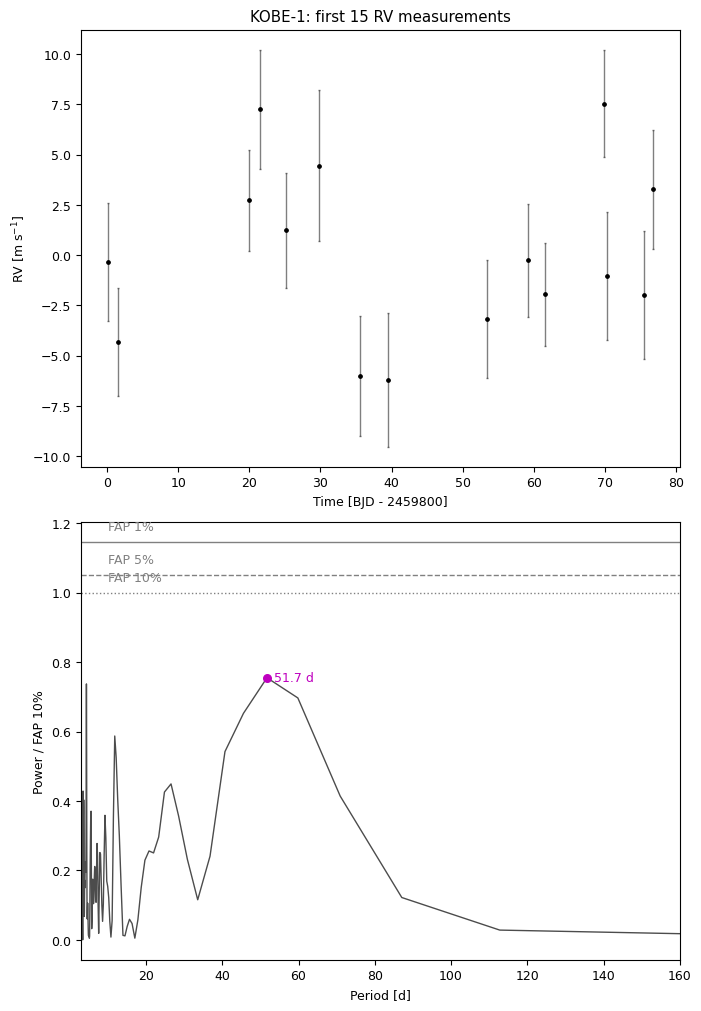

In [7]:
fig, (ax_rv, ax_gls) = plt.subplots(2, 1, figsize = (6.9, 10), constrained_layout = True)

time_zero = int(np.floor(data.jd.min()))
ax_rv.errorbar(
    data.jd - time_zero, data.rv, yerr = data.erv, color = "k", linestyle = "none",
    alpha = 0.5, capsize = 1, linewidth = 1)
ax_rv.scatter(data.jd - time_zero, data.rv, color = "k", edgecolor = "w", lw = 1, s = 20)
ax_rv.set(xlabel = f"Time [BJD - {time_zero + BJD_offset}]",
          ylabel = "RV [m s$^{-1}$]",
          title = f"{star}: first {len(data.rv)} RV measurements")

ax_gls.plot(period, power / fap_10, color = "k", lw = 1, alpha = 0.7)
for level, label, linestyle in [(fap_10, "FAP 10%", ":"), (fap_05, "FAP 5%", "--"), (fap_01, "FAP 1%", "-")]:
    normalized_level = level / fap_10
    ax_gls.axhline(normalized_level, color = "grey", lw = 1, ls = linestyle)
    ax_gls.text(10, normalized_level + 0.025, label, color = "grey", fontsize = 9, va = "bottom")

for index, peak in enumerate(peaks[:n_peaks]):
    color = peak_colors[index % len(peak_colors)]
    peak_period = period[peak]
    peak_power = power[peak] / fap_10
    ax_gls.scatter(peak_period, peak_power, color = color, s = 30, zorder = 3)
    ax_gls.annotate(f"{peak_period:.1f} d", (peak_period, peak_power), xytext = (5, 0),
                    textcoords = "offset points", color = color, fontsize = 9, va = "center")

ax_gls.set(xlim = (min_per_d, max_per_d), xlabel = "Period [d]", ylabel = "Power / FAP 10%")
plt.show()

In [ ]:
# save sub-dataset to use later
data.to_csv(f'data/mock_rv_20Me_60d_first{n_data}_new.csv', index = 0)